In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/horsek/shapenetpart-hdf5-2048/train1_id2file.json
/kaggle/input/datasets/horsek/shapenetpart-hdf5-2048/test0_id2file.json
/kaggle/input/datasets/horsek/shapenetpart-hdf5-2048/val0_id2file.json
/kaggle/input/datasets/horsek/shapenetpart-hdf5-2048/train3_id2file.json
/kaggle/input/datasets/horsek/shapenetpart-hdf5-2048/val0.h5
/kaggle/input/datasets/horsek/shapenetpart-hdf5-2048/train3_id2name.json
/kaggle/input/datasets/horsek/shapenetpart-hdf5-2048/test1_id2file.json
/kaggle/input/datasets/horsek/shapenetpart-hdf5-2048/train0_id2file.json
/kaggle/input/datasets/horsek/shapenetpart-hdf5-2048/train3.h5
/kaggle/input/datasets/horsek/shapenetpart-hdf5-2048/train5.h5
/kaggle/input/datasets/horsek/shapenetpart-hdf5-2048/test1.h5
/kaggle/input/datasets/horsek/shapenetpart-hdf5-2048/train1_id2name.json
/kaggle/input/datasets/horsek/shapenetpart-hdf5-2048/test0.h5
/kaggle/input/datasets/horsek/shapenetpart-hdf5-2048/train2_id2name.json
/kaggle/input/datasets/horsek/shapen

Using device: cuda
Successfully loaded 12137 train samples.
Successfully loaded 1870 val samples.
Successfully loaded 2874 test samples.

Started Training.......
Epoch 1 - Train Loss: 0.9290 | Train Acc: 76.78% || Val Loss: 0.4580 | Val Acc: 85.96%
Epoch 2 - Train Loss: 0.5416 | Train Acc: 84.96% || Val Loss: 0.3659 | Val Acc: 88.28%
Epoch 3 - Train Loss: 0.4488 | Train Acc: 87.02% || Val Loss: 0.3067 | Val Acc: 90.14%
Epoch 4 - Train Loss: 0.3970 | Train Acc: 88.34% || Val Loss: 0.2901 | Val Acc: 90.35%
Epoch 5 - Train Loss: 0.3559 | Train Acc: 89.32% || Val Loss: 0.2738 | Val Acc: 91.28%
Epoch 6 - Train Loss: 0.3482 | Train Acc: 89.65% || Val Loss: 0.2601 | Val Acc: 91.45%
Epoch 7 - Train Loss: 0.3147 | Train Acc: 90.40% || Val Loss: 0.2551 | Val Acc: 91.42%
Epoch 8 - Train Loss: 0.2973 | Train Acc: 90.81% || Val Loss: 0.2605 | Val Acc: 91.49%
Epoch 9 - Train Loss: 0.2939 | Train Acc: 90.87% || Val Loss: 0.2490 | Val Acc: 91.98%
Epoch 10 - Train Loss: 0.2835 | Train Acc: 91.27% || Va

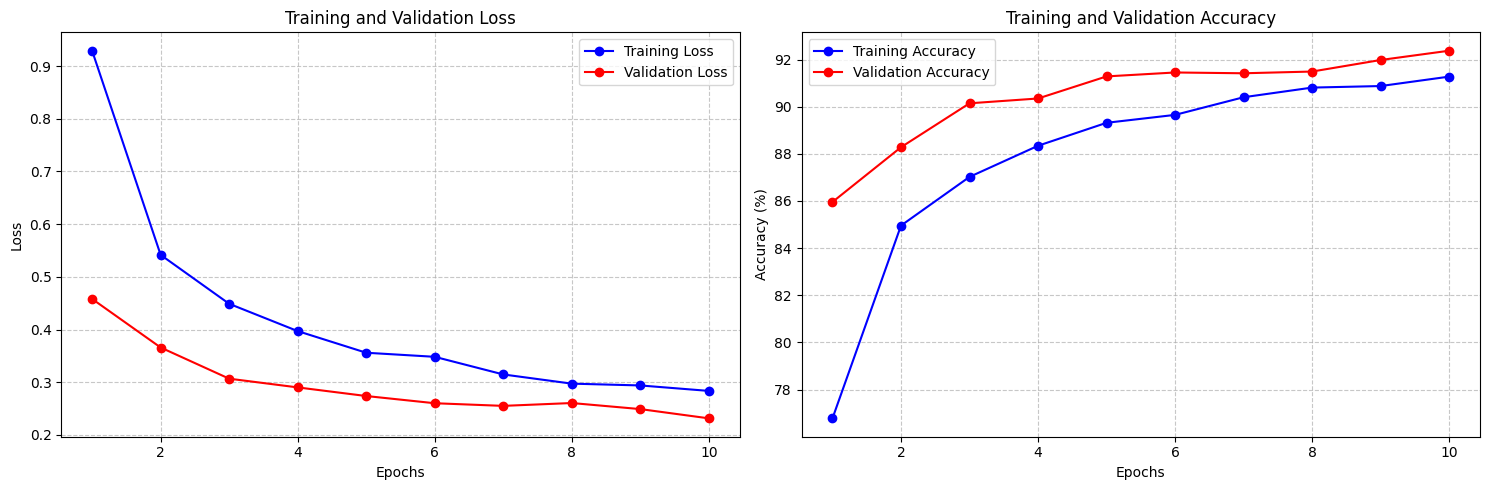


🚀 Evaluating on Test Set...
✅ Final Test Loss: 0.3065 - Final Test Acc: 90.56%


--- Plotting Class-wise F1-Scores ---


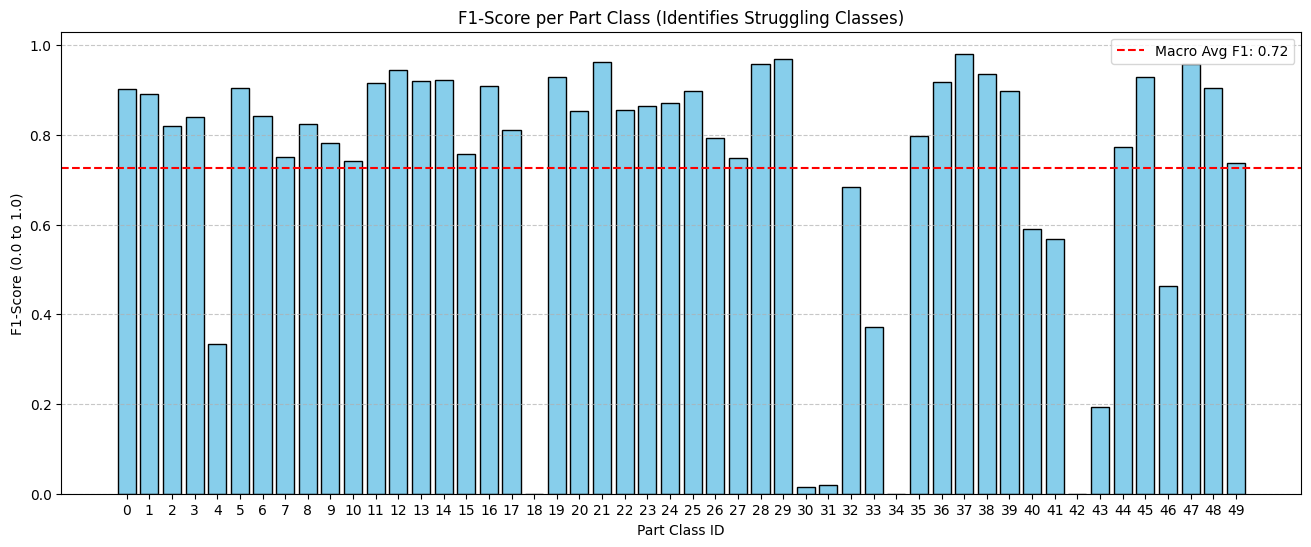


--- Plotting Normalized Confusion Matrix ---


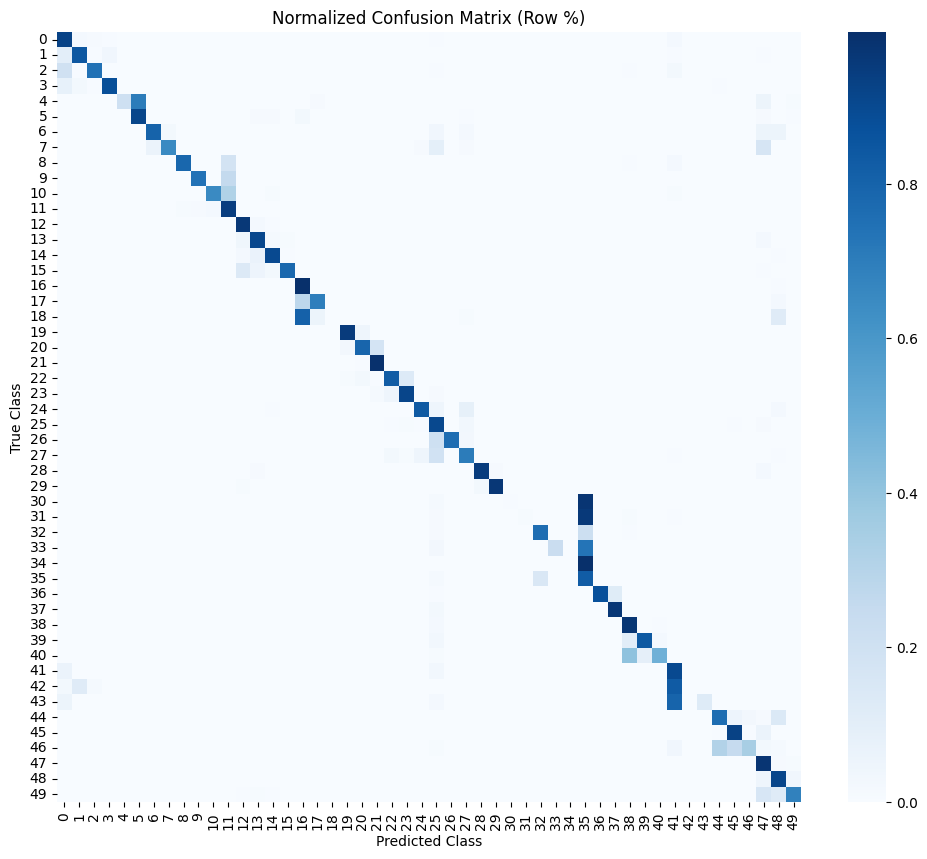


--- Visualizing Random Test Sample ---


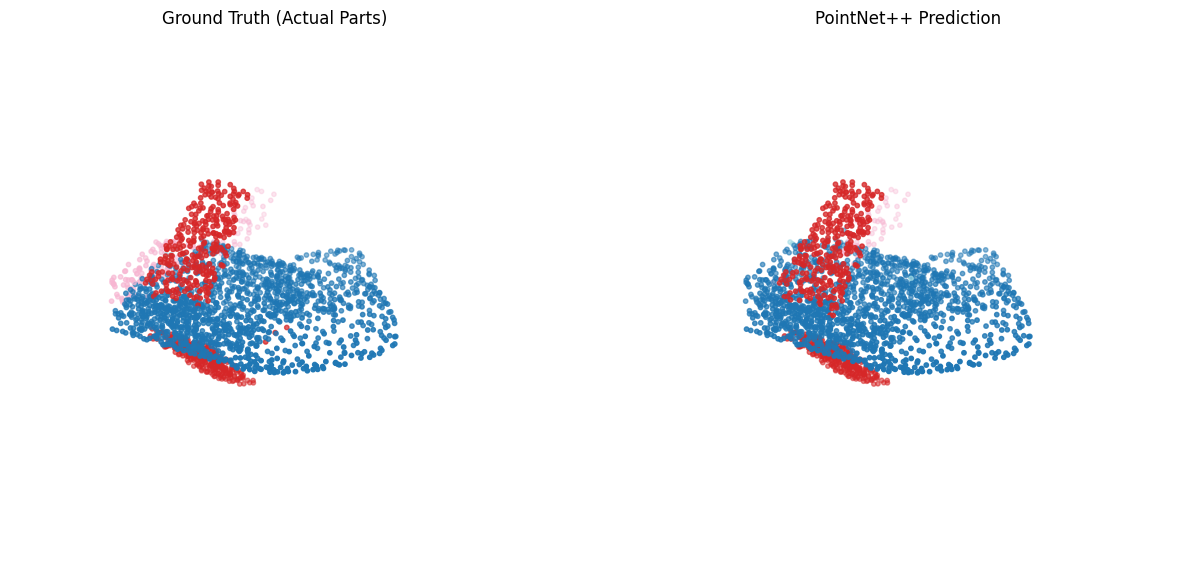

In [7]:
import os
import glob
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import random

# ==========================================
# 1. SHAPENET PART DATASET LOADER
# ==========================================
class ShapeNetPartHDF5Dataset(Dataset):
    def __init__(self, root_dir, split='train', num_points=2048):
        self.num_points = num_points
        self.data = []
        self.labels = [] 
        
        h5_paths = glob.glob(os.path.join(root_dir, f'*{split}*.h5'))
        if len(h5_paths) == 0:
            print(f"❌ ERROR: No .h5 files found for split '{split}' in {root_dir}")
            return

        for h5_name in h5_paths:
            with h5py.File(h5_name, 'r') as f:
                self.data.extend(f['data'][:]) 
                self.labels.extend(f['seg'][:]) 
                
        self.data = np.array(self.data)
        self.labels = np.array(self.labels)
        print(f"Successfully loaded {len(self.data)} {split} samples.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        point_set = self.data[idx][:self.num_points, :].astype(np.float32)
        labels = self.labels[idx][:self.num_points].astype(np.int64)

        # Normalization
        point_set = point_set - np.mean(point_set, axis=0)
        dist = np.max(np.sqrt(np.sum(point_set ** 2, axis=1)), 0)
        point_set = point_set / (dist + 1e-8) 

        return torch.from_numpy(point_set), torch.from_numpy(labels)

# ==========================================
# 2. UTILITIES (FPS, Distance, Indexing)
# ==========================================
def index_points(points, idx):
    device = points.device
    B = points.shape[0]
    view_shape = list(idx.shape)
    view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape)
    repeat_shape[0] = 1
    batch_indices = torch.arange(B, dtype=torch.long).to(device).view(view_shape).repeat(repeat_shape)
    new_points = points[batch_indices, idx, :]
    return new_points

def square_distance(src, dst):
    B, N, _ = src.shape
    _, M, _ = dst.shape
    dist = -2 * torch.matmul(src, dst.permute(0, 2, 1))
    dist += torch.sum(src ** 2, -1).view(B, N, 1)
    dist += torch.sum(dst ** 2, -1).view(B, 1, M)
    return dist

def farthest_point_sample(xyz, npoint):
    device = xyz.device
    B, N, C = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long).to(device)
    distance = torch.ones(B, N).to(device) * 1e10
    farthest = torch.randint(0, N, (B,), dtype=torch.long).to(device)
    batch_indices = torch.arange(B, dtype=torch.long).to(device)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_indices, farthest, :].view(B, 1, 3)
        dist = torch.sum((xyz - centroid) ** 2, -1)
        mask = dist < distance
        distance[mask] = dist[mask]
        farthest = torch.max(distance, -1)[1]
    return centroids

def query_ball_point(radius, nsample, xyz, new_xyz):
    device = xyz.device
    B, N, C = xyz.shape
    _, S, _ = new_xyz.shape
    group_idx = torch.arange(N, dtype=torch.long).to(device).view(1, 1, N).repeat([B, S, 1])
    sqrdists = square_distance(new_xyz, xyz)
    group_idx[sqrdists > radius ** 2] = N
    group_idx = group_idx.sort(dim=-1)[0][:, :, :nsample]
    group_first = group_idx[:, :, 0].view(B, S, 1).repeat([1, 1, nsample])
    mask = group_idx == N
    group_idx[mask] = group_first[mask]
    return group_idx

# ==========================================
# 3. POINTNET++ MODULES (SA & FP)
# ==========================================
class PointNetSetAbstraction(nn.Module):
    def __init__(self, npoint, radius, nsample, in_channel, mlp):
        super(PointNetSetAbstraction, self).__init__()
        self.npoint, self.radius, self.nsample = npoint, radius, nsample
        self.mlp_convs = nn.ModuleList()
        self.mlp_bns = nn.ModuleList()
        last_channel = in_channel
        for out_channel in mlp:
            self.mlp_convs.append(nn.Conv2d(last_channel, out_channel, 1))
            self.mlp_bns.append(nn.BatchNorm2d(out_channel))
            last_channel = out_channel

    def forward(self, xyz, points):
        B, N, C = xyz.shape
        if self.npoint is not None:
            fps_idx = farthest_point_sample(xyz, self.npoint)
            new_xyz = index_points(xyz, fps_idx)
        else:
            new_xyz = torch.zeros(B, 1, 3).to(xyz.device)
            
        if self.npoint is not None:
            idx = query_ball_point(self.radius, self.nsample, xyz, new_xyz)
            grouped_xyz = index_points(xyz, idx)
            grouped_xyz -= new_xyz.unsqueeze(2)
            if points is not None:
                grouped_points = index_points(points, idx)
                grouped_points = torch.cat([grouped_xyz, grouped_points], dim=-1)
            else:
                grouped_points = grouped_xyz
        else:
            grouped_points = xyz.unsqueeze(1)
            if points is not None:
                grouped_points = torch.cat([grouped_points, points.unsqueeze(1)], dim=-1)

        grouped_points = grouped_points.permute(0, 3, 2, 1)
        for i, conv in enumerate(self.mlp_convs):
            grouped_points = F.relu(self.mlp_bns[i](conv(grouped_points)))
        new_points = torch.max(grouped_points, 2)[0].transpose(1, 2)
        return new_xyz, new_points

class PointNetFeaturePropagation(nn.Module):
    def __init__(self, in_channel, mlp):
        super(PointNetFeaturePropagation, self).__init__()
        self.mlp_convs = nn.ModuleList()
        self.mlp_bns = nn.ModuleList()
        last_channel = in_channel
        for out_channel in mlp:
            self.mlp_convs.append(nn.Conv1d(last_channel, out_channel, 1))
            self.mlp_bns.append(nn.BatchNorm1d(out_channel))
            last_channel = out_channel

    def forward(self, xyz1, xyz2, points1, points2):
        B, N, C = xyz1.shape
        _, S, _ = xyz2.shape

        if S == 1:
            interpolated_points = points2.repeat(1, N, 1)
        else:
            dists = square_distance(xyz1, xyz2)
            dists, idx = dists.sort(dim=-1)
            dists, idx = dists[:, :, :3], idx[:, :, :3]
            dist_recip = 1.0 / (dists + 1e-8)
            norm = torch.sum(dist_recip, dim=2, keepdim=True)
            weight = dist_recip / norm
            interpolated_points = torch.sum(index_points(points2, idx) * weight.unsqueeze(-1), dim=2)

        if points1 is not None:
            new_points = torch.cat([points1, interpolated_points], dim=-1)
        else:
            new_points = interpolated_points

        new_points = new_points.permute(0, 2, 1)
        for i, conv in enumerate(self.mlp_convs):
            new_points = F.relu(self.mlp_bns[i](conv(new_points)))
        return new_points.transpose(1, 2)

# ==========================================
# 4. POINTNET++ PART SEGMENTATION MODEL
# ==========================================
class PointNet2PartSeg(nn.Module):
    def __init__(self, num_classes=50):
        super(PointNet2PartSeg, self).__init__()
        self.sa1 = PointNetSetAbstraction(512, 0.2, 32, 3, [64, 64, 128])
        self.sa2 = PointNetSetAbstraction(128, 0.4, 64, 128 + 3, [128, 128, 256])
        self.sa3 = PointNetSetAbstraction(None, None, None, 256 + 3, [256, 512, 1024])
        
        self.fp3 = PointNetFeaturePropagation(1024 + 256, [256, 256])
        self.fp2 = PointNetFeaturePropagation(256 + 128, [256, 128])
        self.fp1 = PointNetFeaturePropagation(128 + 3, [128, 128, 128])

        self.conv1 = nn.Conv1d(128, 128, 1)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.5)
        self.conv2 = nn.Conv1d(128, num_classes, 1)

    def forward(self, xyz):
        l0_xyz = xyz
        l0_points = None
        l1_xyz, l1_points = self.sa1(l0_xyz, l0_points)
        l2_xyz, l2_points = self.sa2(l1_xyz, l1_points)
        l3_xyz, l3_points = self.sa3(l2_xyz, l2_points)

        l2_points = self.fp3(l2_xyz, l3_xyz, l2_points, l3_points)
        l1_points = self.fp2(l1_xyz, l2_xyz, l1_points, l2_points)
        l0_points = self.fp1(l0_xyz, l1_xyz, l0_xyz, l1_points)

        x = l0_points.permute(0, 2, 1)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.drop1(x)
        x = self.conv2(x)
        return F.log_softmax(x, dim=1)

# ==========================================
# 5. VISUALIZERS & PLOTTING UTILS (NEWLY ADDED)
# ==========================================
def plot_learning_curves(history):
    """Plots Training & Validation Loss and Accuracy side-by-side."""
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss Plot
    ax1.plot(epochs, history['train_loss'], 'bo-', label='Training Loss')
    ax1.plot(epochs, history['val_loss'], 'ro-', label='Validation Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Accuracy Plot
    ax2.plot(epochs, history['train_acc'], 'bo-', label='Training Accuracy')
    ax2.plot(epochs, history['val_acc'], 'ro-', label='Validation Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def plot_class_f1_scores(targets, preds):
    """Plots a bar chart of F1-Scores for each individual class."""
    report = classification_report(targets, preds, output_dict=True, zero_division=0)
    
    # Extract only the numbered classes (ignore 'accuracy', 'macro avg', etc.)
    classes = []
    f1_scores = []
    for key, value in report.items():
        if key.isdigit():
            classes.append(int(key))
            f1_scores.append(value['f1-score'])
            
    plt.figure(figsize=(16, 6))
    bars = plt.bar(classes, f1_scores, color='skyblue', edgecolor='black')
    
    # Add a red line to indicate the overall macro average
    macro_f1 = report['macro avg']['f1-score']
    plt.axhline(y=macro_f1, color='red', linestyle='--', label=f'Macro Avg F1: {macro_f1:.2f}')
    
    plt.title('F1-Score per Part Class (Identifies Struggling Classes)')
    plt.xlabel('Part Class ID')
    plt.ylabel('F1-Score (0.0 to 1.0)')
    plt.xticks(classes) 
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def visualize_random_prediction(model, dataset, device):
    """3D Plot of Ground Truth vs Prediction."""
    model.eval()
    idx = random.randint(0, len(dataset) - 1)
    points, target = dataset[idx]
    
    points_batch = points.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(points_batch)
        pred = output.argmax(dim=1).squeeze(0).cpu().numpy()
        
    points_np = points.numpy()
    target_np = target.numpy()
    
    fig = plt.figure(figsize=(15, 7))
    
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(points_np[:, 0], points_np[:, 1], points_np[:, 2], c=target_np, cmap='tab20', s=10)
    ax1.set_title("Ground Truth (Actual Parts)")
    ax1.axis('off')
    
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(points_np[:, 0], points_np[:, 1], points_np[:, 2], c=pred, cmap='tab20', s=10)
    ax2.set_title("PointNet++ Prediction")
    ax2.axis('off')
    
    plt.show()

# ==========================================
# 6. TRAINING & EVALUATION PIPELINE
# ==========================================
def run_segmentation():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    DATA_DIR = None
    for root, _, files in os.walk('/kaggle/input'):
        if any('.h5' in f for f in files):
            DATA_DIR = root
            break
            
    if DATA_DIR is None:
        print("❌ ERROR: Could not find dataset directory.")
        return

    train_ds = ShapeNetPartHDF5Dataset(DATA_DIR, split='train')
    val_ds = ShapeNetPartHDF5Dataset(DATA_DIR, split='val')
    test_ds = ShapeNetPartHDF5Dataset(DATA_DIR, split='test')
    
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, drop_last=False)
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, drop_last=False)

    model = PointNet2PartSeg(num_classes=50).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.NLLLoss()

    # Dictionary to track metrics for plotting
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print("\nStarted Training.......")
    for epoch in range(10):
        # --- TRAINING ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for points, target in train_loader:
            points, target = points.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(points)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_correct += (output.argmax(dim=1) == target).sum().item()
            train_total += target.numel() 

        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100. * train_correct / train_total
        
        # --- VALIDATION ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for points, target in val_loader:
                points, target = points.to(device), target.to(device)
                output = model(points)
                loss = criterion(output, target)
                val_loss += loss.item()
                val_correct += (output.argmax(dim=1) == target).sum().item()
                val_total += target.numel()

        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        
        # Save metrics to history dictionary
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% || Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Save Model
    save_path = "pointnet2_partseg_model.pth"
    torch.save(model.state_dict(), save_path)
    print(f"\n💾 Model weights saved to: {save_path}")

    # --- NEW: Plot Training Curves ---
    print("\n--- Plotting Learning Curves ---")
    plot_learning_curves(history)

    # --- TEST EVALUATION ---
    print("\n==========================================")
    print("🚀 Evaluating on Test Set...")
    model.eval()
    test_loss, test_correct, test_total = 0, 0, 0
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for points, target in test_loader:
            points, target = points.to(device), target.to(device)
            output = model(points)
            loss = criterion(output, target)
            test_loss += loss.item()
            
            preds = output.argmax(dim=1)
            test_correct += (preds == target).sum().item()
            test_total += target.numel()
            
            all_preds.append(preds.view(-1).cpu().numpy())
            all_targets.append(target.view(-1).cpu().numpy())

    test_acc = 100. * test_correct / test_total
    print(f"✅ Final Test Loss: {test_loss/len(test_loader):.4f} - Final Test Acc: {test_acc:.2f}%\n")

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    # --- NEW: Plot F1 Bar Chart ---
    print("\n--- Plotting Class-wise F1-Scores ---")
    plot_class_f1_scores(all_targets, all_preds)

    # Confusion Matrix (Normalized)
    print("\n--- Plotting Normalized Confusion Matrix ---")
    cm = confusion_matrix(all_targets, all_preds, normalize='true') 
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap='Blues', fmt='.2f')
    plt.title('Normalized Confusion Matrix (Row %)')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()

    # 3D Visualizer
    print("\n--- Visualizing Random Test Sample ---")
    visualize_random_prediction(model, test_ds, device)

    return model

# Run it!
model = run_segmentation()